In [1]:
%pip install numpy pandas scipy scikit-learn matplotlib seaborn yfinance requests tqdm jupyterlab


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 0 — Imports and Global Config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import kstest, expon
from sklearn.mixture import GaussianMixture
import yfinance as yf
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')

# --- Plot style ---
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# --- Paths — edit RAW_DIR to where your Dukascopy CSVs live ---
RAW_DIR   = Path("./download3")   # ← change this
OUT_DIR   = Path("./hawkes_output")
OUT_DIR.mkdir(exist_ok=True)

# --- Regime thresholds (placeholder — Phase 1 will compute real ones) ---
THRESH = {"quiet_max": 15, "trending_max": 25}

print("✅ Imports done")
print(f"   RAW_DIR  : {RAW_DIR}")
print(f"   OUT_DIR  : {OUT_DIR}")

✅ Imports done
   RAW_DIR  : download3
   OUT_DIR  : hawkes_output


✅ VIX downloaded: 252 trading days
   Range  : 2019-07-01 → 2020-06-29
   Missing: 0 days

   Percentiles:
     10th : 12.58
     25th : 13.60
     33th : 14.08
     50th : 16.53
     67th : 26.95
     75th : 31.77
     90th : 41.98


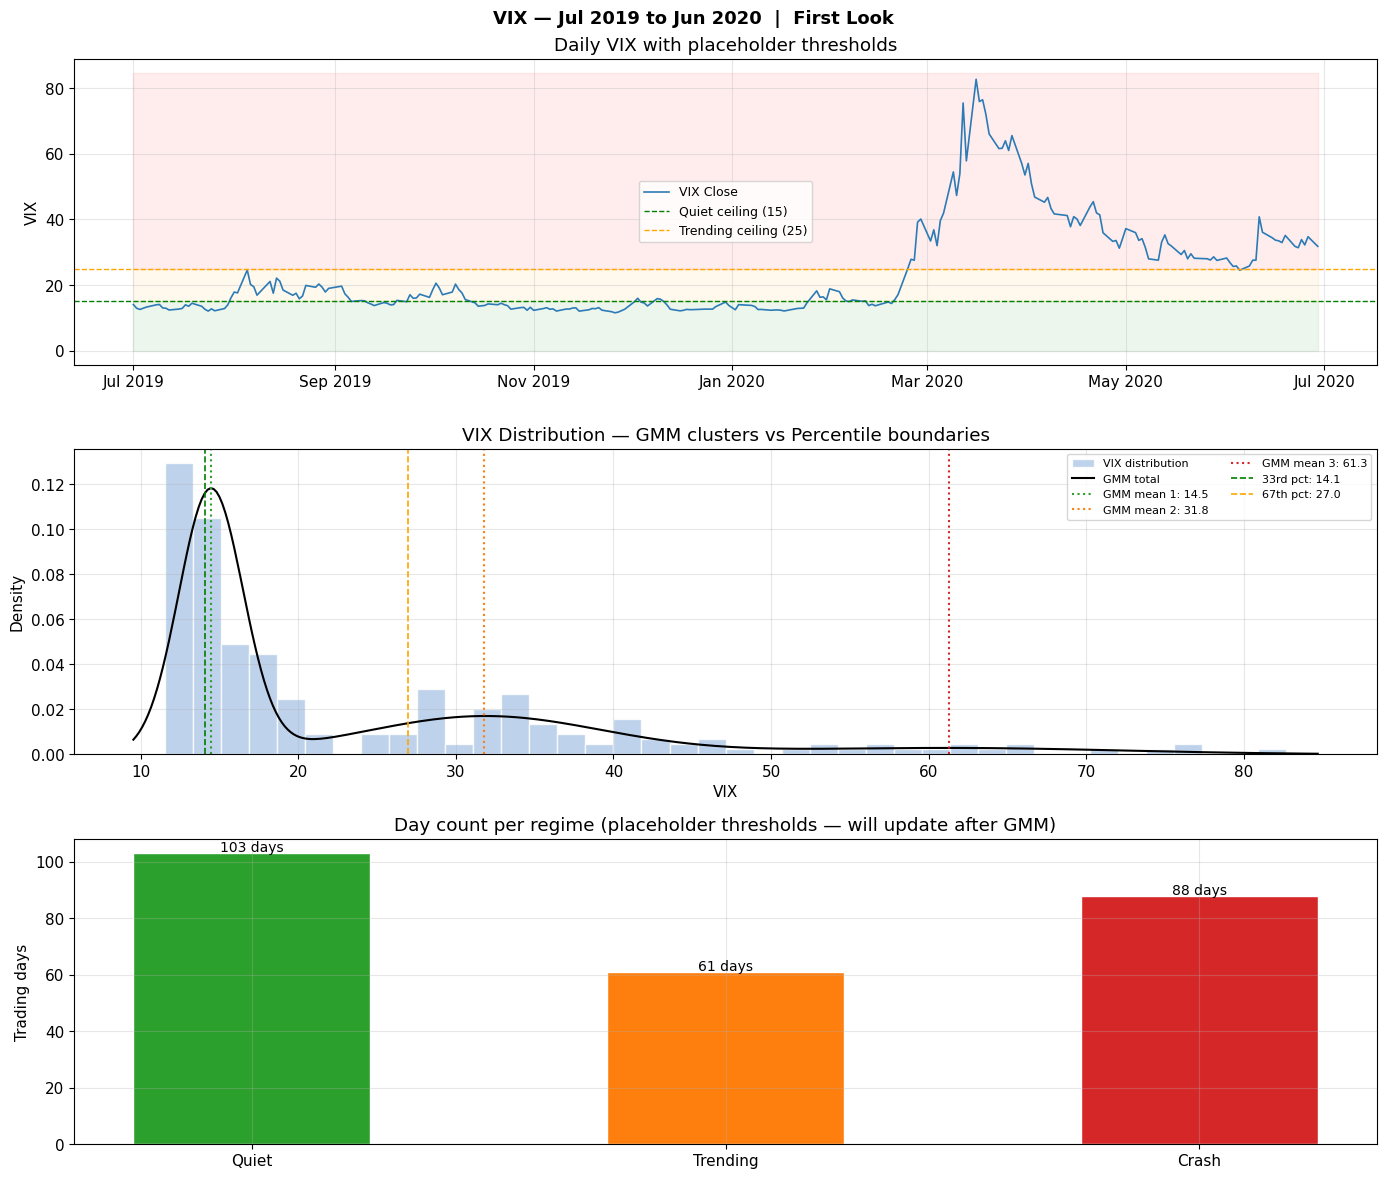


   GMM component means : ['14.46', '31.80', '61.29']
   33rd / 67th pct     : 14.08 / 26.95

👉 Look at Panel 1 and tell me the time window where all 3 regimes are visible.
   We will lock that window before touching any tick data.


In [3]:
# Cell 1 — VIX Download and Inspection

# --- Download ---
vix_raw = yf.download("^VIX", start="2019-07-01", end="2020-06-30", auto_adjust=True, progress=False)
vix = vix_raw[["Close"]].copy()
vix.columns = ["vix"]
vix.index = pd.to_datetime(vix.index)
if isinstance(vix.index, pd.DatetimeIndex) and vix.index.tz is not None:
    vix.index = vix.index.tz_localize(None)

print(f"✅ VIX downloaded: {len(vix)} trading days")
print(f"   Range  : {vix.index[0].date()} → {vix.index[-1].date()}")
print(f"   Missing: {vix['vix'].isna().sum()} days")
print(f"\n   Percentiles:")
for p in [10, 25, 33, 50, 67, 75, 90]:
    print(f"     {p}th : {vix['vix'].quantile(p/100):.2f}")

# --- Figure: 3 panels ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("VIX — Jul 2019 to Jun 2020  |  First Look", fontsize=13, fontweight='bold')

# Panel 1 — Time series
ax = axes[0]
ax.plot(vix.index, vix["vix"], color="#2c7bb6", linewidth=1.2, label="VIX Close")
ax.axhline(15, color="green",  linestyle="--", linewidth=1, label="Quiet ceiling (15)")
ax.axhline(25, color="orange", linestyle="--", linewidth=1, label="Trending ceiling (25)")
ax.fill_between(vix.index, 0,  15, alpha=0.07, color="green")
ax.fill_between(vix.index, 15, 25, alpha=0.07, color="orange")
ax.fill_between(vix.index, 25, vix["vix"].max()+2, alpha=0.07, color="red")
ax.set_ylabel("VIX")
ax.set_title("Daily VIX with placeholder thresholds")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Panel 2 — Distribution + GMM
ax = axes[1]
vals = vix["vix"].dropna().values.reshape(-1, 1)
gmm = GaussianMixture(n_components=3, random_state=42, n_init=10)
gmm.fit(vals)
means = sorted(gmm.means_.flatten())

x_range = np.linspace(vals.min()-2, vals.max()+2, 400).reshape(-1, 1)
colors_gmm = ["#2ca02c", "#ff7f0e", "#d62728"]
ax.hist(vix["vix"].dropna(), bins=40, density=True,
        color="#aec7e8", edgecolor="white", alpha=0.8, label="VIX distribution")

log_prob = gmm.score_samples(x_range)
ax.plot(x_range, np.exp(log_prob), color="black", linewidth=1.5, label="GMM total")
for i, (mean, col) in enumerate(zip(means, colors_gmm)):
    ax.axvline(mean, color=col, linestyle=":", linewidth=1.5, label=f"GMM mean {i+1}: {mean:.1f}")

p33 = vix["vix"].quantile(0.33)
p67 = vix["vix"].quantile(0.67)
ax.axvline(p33, color="green",  linestyle="--", linewidth=1.2, label=f"33rd pct: {p33:.1f}")
ax.axvline(p67, color="orange", linestyle="--", linewidth=1.2, label=f"67th pct: {p67:.1f}")
ax.set_xlabel("VIX")
ax.set_ylabel("Density")
ax.set_title("VIX Distribution — GMM clusters vs Percentile boundaries")
ax.legend(fontsize=8, ncol=2)

# Panel 3 — Regime day count under placeholder thresholds
ax = axes[2]
labels = np.where(vix["vix"] < 15, "Quiet",
         np.where(vix["vix"] < 25, "Trending", "Crash"))
counts = pd.Series(labels).value_counts().reindex(["Quiet","Trending","Crash"]).fillna(0)
bars = ax.bar(counts.index, counts.values,
              color=["#2ca02c","#ff7f0e","#d62728"], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{int(val)} days", ha="center", fontsize=10)
ax.set_ylabel("Trading days")
ax.set_title("Day count per regime (placeholder thresholds — will update after GMM)")

plt.tight_layout()
plt.savefig(OUT_DIR / "cell1_vix_inspection.png", dpi=150)
plt.show()

print(f"\n   GMM component means : {[f'{m:.2f}' for m in means]}")
print(f"   33rd / 67th pct     : {p33:.2f} / {p67:.2f}")
print(f"\n👉 Look at Panel 1 and tell me the time window where all 3 regimes are visible.")
print(f"   We will lock that window before touching any tick data.")

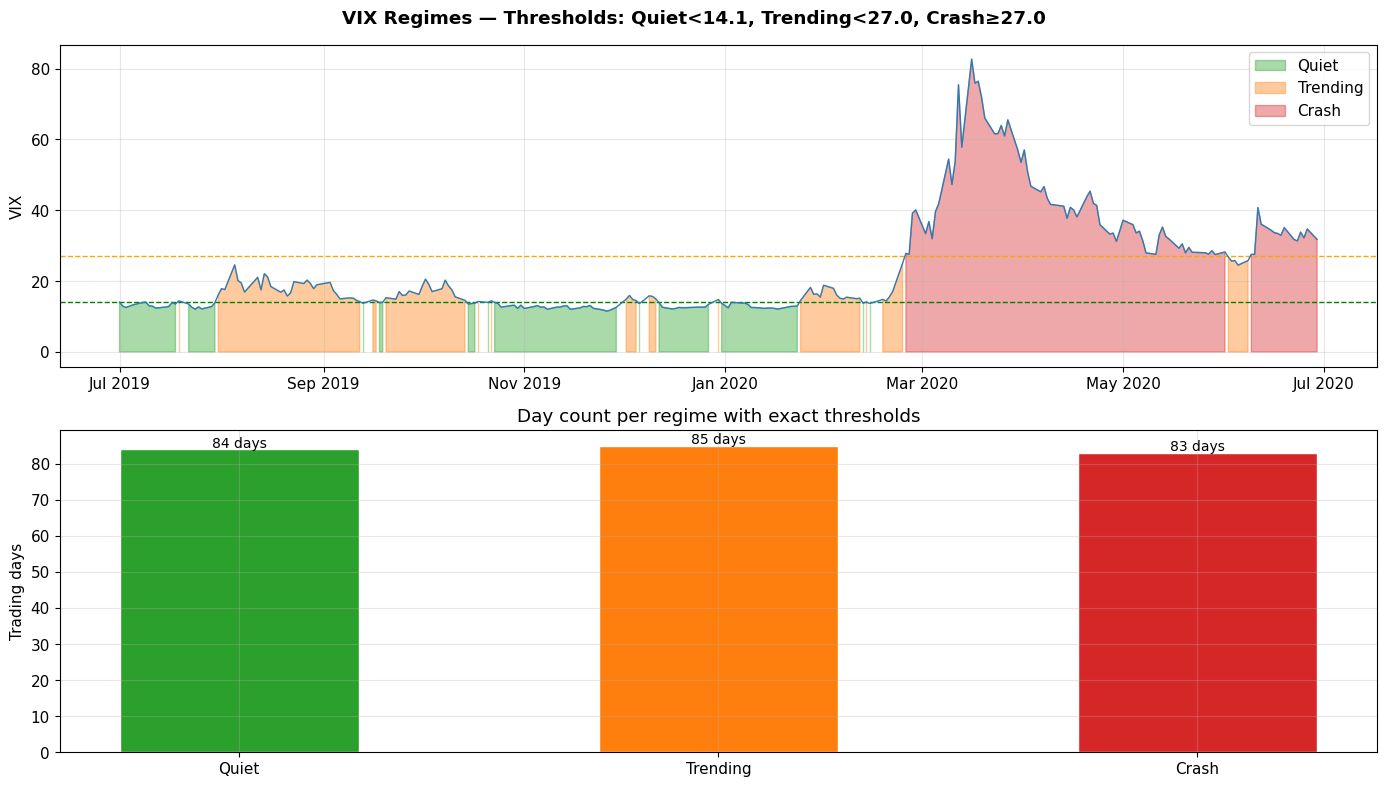


Regime summary:
          count    min    max   mean
regime                              
Crash        83  27.51  82.69  41.19
Quiet        84  11.54  14.09  12.97
Trending     85  14.15  26.84  17.49


In [4]:
# Cell 1b — Verify exact GMM thresholds on timeline

Q_MAX  = 14.1
T_MAX  = 27.0

vix["regime"] = np.where(vix["vix"] < Q_MAX, "Quiet",
                np.where(vix["vix"] < T_MAX, "Trending", "Crash"))

colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(f"VIX Regimes — Thresholds: Quiet<{Q_MAX}, Trending<{T_MAX}, Crash≥{T_MAX}", fontweight='bold')

# Panel 1 — coloured time series
ax = axes[0]
for regime, col in colors.items():
    mask = vix["regime"] == regime
    ax.fill_between(vix.index, vix["vix"], where=mask, alpha=0.4, color=col, label=regime)
ax.plot(vix.index, vix["vix"], color="#2c7bb6", linewidth=1, zorder=5)
ax.axhline(Q_MAX, color="green",  linestyle="--", linewidth=1)
ax.axhline(T_MAX, color="orange", linestyle="--", linewidth=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("VIX")
ax.legend()

# Panel 2 — day count with exact date ranges
ax = axes[1]
summary = vix.groupby("regime").agg(days=("vix","count"), 
                                     start=("vix", lambda x: x.index[0].strftime("%Y-%m-%d")),
                                     end=("vix",   lambda x: x.index[-1].strftime("%Y-%m-%d")))
counts = vix["regime"].value_counts().reindex(["Quiet","Trending","Crash"])
bars = ax.bar(counts.index, counts.values, color=[colors[r] for r in counts.index], 
              edgecolor="white", width=0.5)
for bar, (regime, val) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{int(val)} days", ha="center", fontsize=10)
ax.set_ylabel("Trading days")
ax.set_title("Day count per regime with exact thresholds")

plt.tight_layout()
plt.savefig(OUT_DIR / "cell1b_threshold_verify.png", dpi=150)
plt.show()

print("\nRegime summary:")
print(vix.groupby("regime")["vix"].agg(["count","min","max","mean"]).round(2))


  QUIET — top continuous runs (min 5 trading days)
       start        end  trading_days   vix_mean  vix_min  vix_max
0 2019-10-23 2019-11-29            27  12.692593    11.54    14.01
1 2019-12-31 2020-01-23            16  12.921875    12.10    14.02
2 2019-07-01 2019-07-18            13  13.252308    12.39    14.09
3 2019-12-12 2019-12-27            11  12.722727    12.14    13.94
4 2019-07-22 2019-07-30             7  12.840000    12.07    13.94

  TRENDING — top continuous runs (min 5 trading days)
       start        end  trading_days   vix_mean  vix_min    vix_max
0 2019-07-31 2019-09-12            31  18.103871    14.22  24.590000
1 2019-09-20 2019-10-14            17  17.208823    14.57  20.559999
2 2020-01-24 2020-02-11            13  16.123846    14.56  18.840000
3 2020-02-18 2020-02-24             5  17.376000    14.38  25.030001
4 2020-06-02 2020-06-08             5  25.728000    24.52  26.840000

  CRASH — top continuous runs (min 5 trading days)
       start        end  

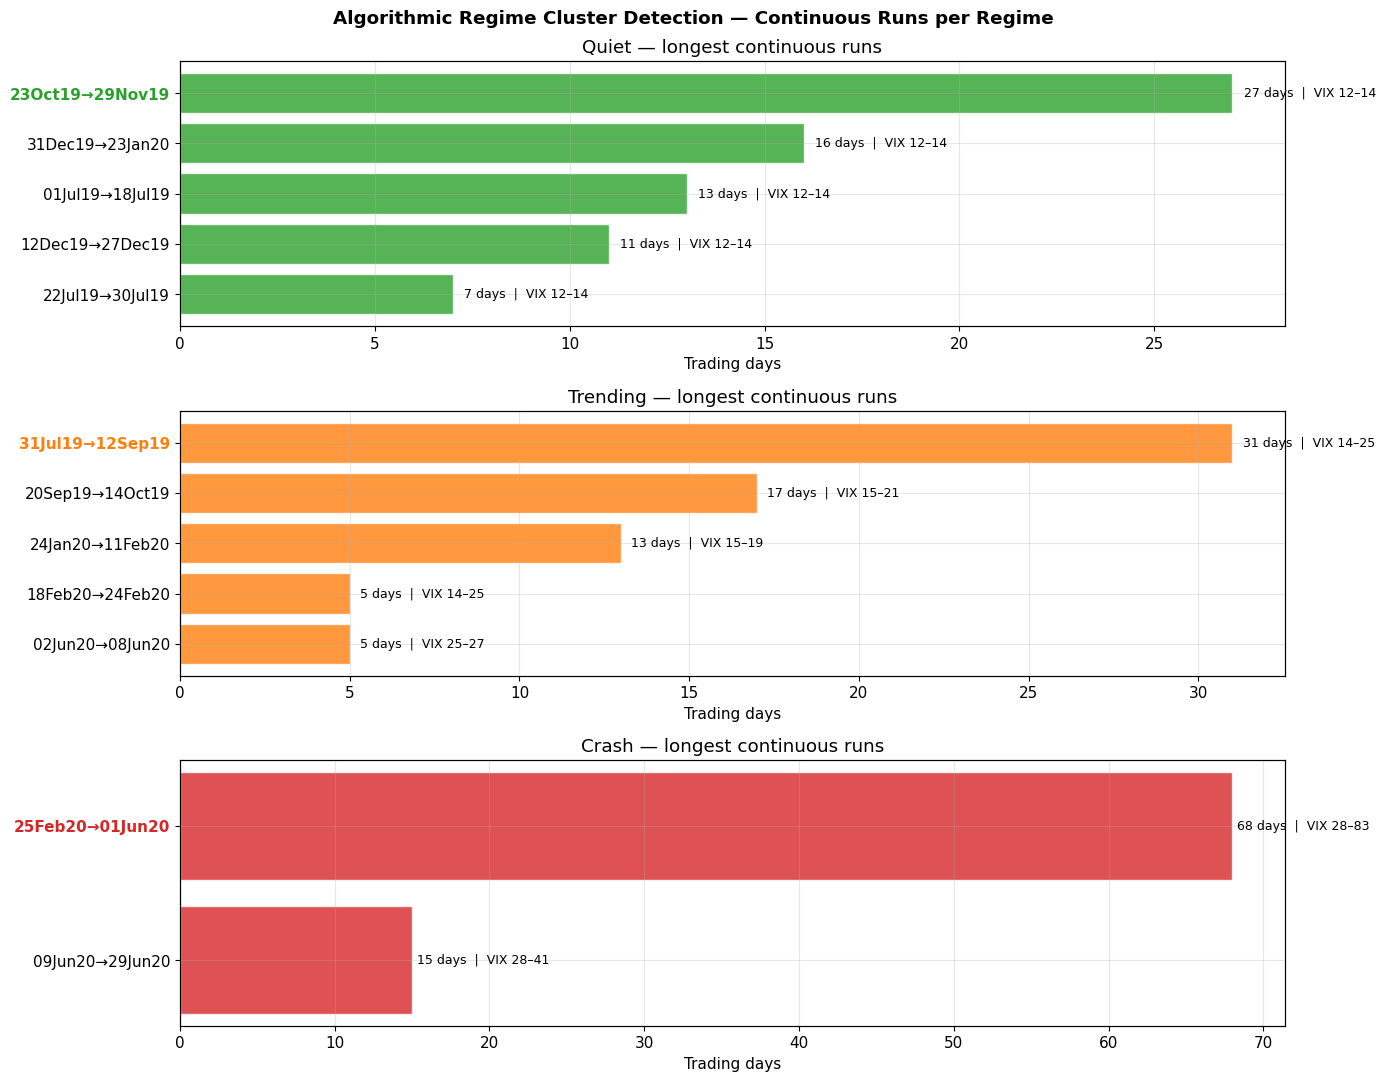

In [5]:
# Cell 2 — Algorithmic Regime Cluster Detection

def find_continuous_runs(vix_df, regime_name, min_days=5):
    """Find all continuous runs of a regime, return sorted by length."""
    mask = vix_df["regime"] == regime_name
    runs = []
    in_run = False
    start_idx = None

    for i, (date, is_regime) in enumerate(zip(vix_df.index, mask)):
        if is_regime and not in_run:
            in_run = True
            start_idx = date
        elif not is_regime and in_run:
            in_run = False
            end_idx = vix_df.index[i - 1]
            days = (vix_df.index[i-1] - start_idx).days
            trading_days = mask[start_idx:end_idx].sum()
            if trading_days >= min_days:
                runs.append({
                    "start": start_idx,
                    "end": end_idx,
                    "trading_days": trading_days,
                    "calendar_days": days,
                    "vix_mean": vix_df.loc[start_idx:end_idx, "vix"].mean(),
                    "vix_min":  vix_df.loc[start_idx:end_idx, "vix"].min(),
                    "vix_max":  vix_df.loc[start_idx:end_idx, "vix"].max(),
                })
    # close last run if still open
    if in_run:
        end_idx = vix_df.index[-1]
        trading_days = mask[start_idx:end_idx].sum()
        if trading_days >= min_days:
            runs.append({
                "start": start_idx,
                "end": end_idx,
                "trading_days": trading_days,
                "calendar_days": (end_idx - start_idx).days,
                "vix_mean": vix_df.loc[start_idx:end_idx, "vix"].mean(),
                "vix_min":  vix_df.loc[start_idx:end_idx, "vix"].min(),
                "vix_max":  vix_df.loc[start_idx:end_idx, "vix"].max(),
            })

    return pd.DataFrame(runs).sort_values("trading_days", ascending=False).reset_index(drop=True)

# --- Run for all three regimes ---
runs = {}
for regime in ["Quiet", "Trending", "Crash"]:
    runs[regime] = find_continuous_runs(vix, regime, min_days=5)

# --- Print results ---
for regime, df in runs.items():
    print(f"\n{'='*55}")
    print(f"  {regime.upper()} — top continuous runs (min 5 trading days)")
    print(f"{'='*55}")
    print(df[["start","end","trading_days","vix_mean","vix_min","vix_max"]]
          .head(5).to_string(index=True))

# --- Identify best bucket per regime (longest clean run) ---
best = {r: runs[r].iloc[0] for r in ["Quiet","Trending","Crash"]}

print("\n" + "="*55)
print("  RECOMMENDED BUCKETS FOR STATISTICAL LEARNING")
print("="*55)
for regime, row in best.items():
    print(f"\n  {regime}")
    print(f"    Start        : {row['start'].date()}")
    print(f"    End          : {row['end'].date()}")
    print(f"    Trading days : {row['trading_days']}")
    print(f"    VIX range    : {row['vix_min']:.1f} – {row['vix_max']:.1f}  (mean {row['vix_mean']:.1f})")

# --- Visualise all runs ---
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
fig.suptitle("Algorithmic Regime Cluster Detection — Continuous Runs per Regime", fontweight='bold')

regime_colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

for ax, regime in zip(axes, ["Quiet", "Trending", "Crash"]):
    df = runs[regime].head(6)
    col = regime_colors[regime]

    # Bar chart of run lengths
    labels = [f"{r['start'].strftime('%d%b%y')}→{r['end'].strftime('%d%b%y')}"
              for _, r in df.iterrows()]
    bars = ax.barh(labels, df["trading_days"], color=col, alpha=0.8, edgecolor="white")

    for bar, (_, row) in zip(bars, df.iterrows()):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{int(row['trading_days'])} days  |  VIX {row['vix_min']:.0f}–{row['vix_max']:.0f}",
                va="center", fontsize=9)

    ax.set_title(f"{regime} — longest continuous runs")
    ax.set_xlabel("Trading days")
    ax.invert_yaxis()

    # Highlight the best (longest) run
    axes_twin = ax.twinx()
    axes_twin.set_yticks([])
    ax.get_yticklabels()[0].set_fontweight('bold')
    ax.get_yticklabels()[0].set_color(col)

plt.tight_layout()
plt.savefig(OUT_DIR / "cell2_regime_clusters.png", dpi=150)
plt.show()


  Quiet: 1 file(s) found
    spyususd-tick-2019-10-23-2019-11-29.csv  →  1,729,865 rows
  Total raw rows : 1,729,865

  Trending: 3 file(s) found
    spyususd-tick-2019-07-31-2019-08-15.csv  →  1,304,087 rows
    spyususd-tick-2019-08-15-2019-08-31.csv  →  1,035,104 rows
    spyususd-tick-2019-08-31-2019-09-19.csv  →  986,779 rows
  Total raw rows : 3,325,970

  Crash: 4 file(s) found
    spyususd-tick-2020-02-25-2020-02-29.csv  →  893,314 rows
    spyususd-tick-2020-03-01-2020-03-05.csv  →  681,322 rows
    spyususd-tick-2020-03-06-2020-03-10.csv  →  467,468 rows
    spyususd-tick-2020-03-11-2020-03-15.csv  →  724,916 rows
  Total raw rows : 2,767,020

  CLEANING AUDIT

  Quiet
    after_ts_fix             :  1,729,865
    after_rth                :  1,357,001
    after_gap_remove         :  1,356,974
    after_dt_zero            :  1,356,974
    after_outlier_cap        :  1,355,619
    final_rows               :  1,355,619
    dt_mean (s)              :     0.3685
    dt_median (s)

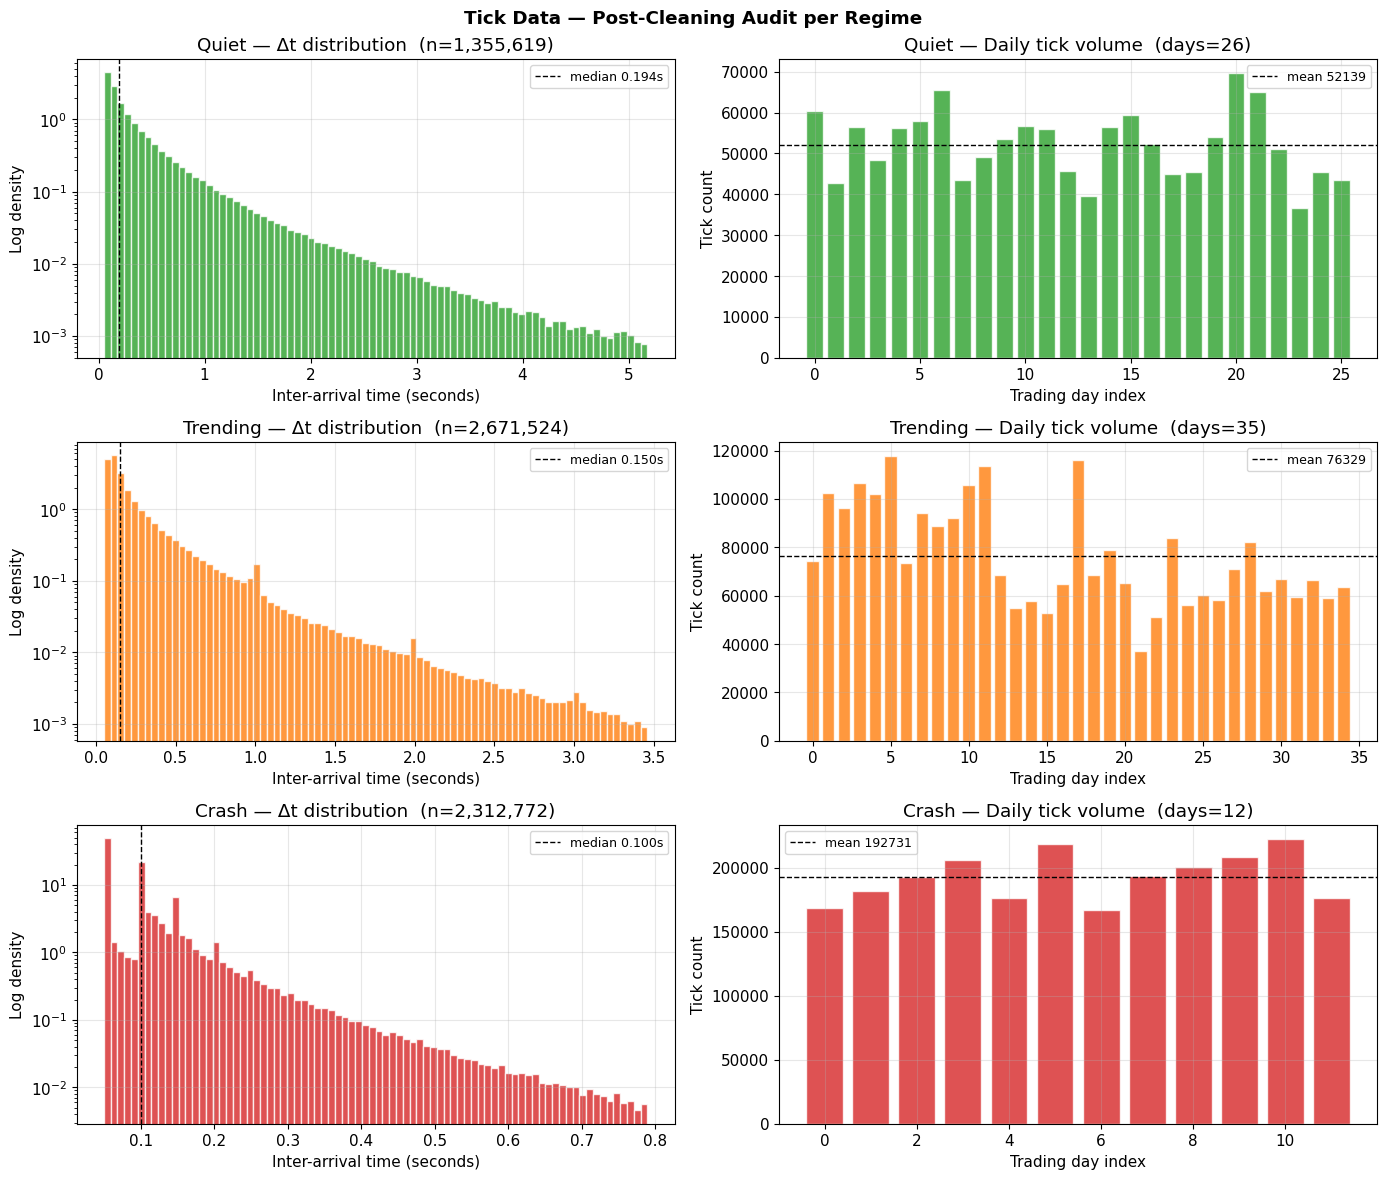

In [6]:
# Cell 3 — Load, Clean and Audit Tick Data per Regime

import glob

REGIME_DIRS = {
    "Quiet":    RAW_DIR / "quiet",
    "Trending": RAW_DIR / "trending",
    "Crash":    RAW_DIR / "crash",
}

RTH_START = "09:30"
RTH_END   = "16:00"

def load_regime_ticks(folder, regime_name):
    files = sorted(glob.glob(str(folder / "*.csv")))
    print(f"\n  {regime_name}: {len(files)} file(s) found")
    
    chunks = []
    for f in files:
        df = pd.read_csv(f, header=0)
        # Dukascopy columns: timestamp, askPrice, bidPrice, askVolume, bidVolume
        df.columns = [c.strip().lower() for c in df.columns]
        # Keep only timestamp — rename flexibly
        ts_col = [c for c in df.columns if "time" in c or "date" in c][0]
        df = df.rename(columns={ts_col: "ts_raw"})
        chunks.append(df[["ts_raw"]])
        print(f"    {Path(f).name}  →  {len(df):,} rows")
    
    raw = pd.concat(chunks, ignore_index=True)
    print(f"  Total raw rows : {len(raw):,}")
    return raw

def clean_ticks(raw, regime_name):
    df = raw.copy()
    stats = {}

    # --- Fix 1: millisecond timestamp ---
    # Dukascopy gives ms integers; pandas reads as ns by default
    df["ts"] = pd.to_datetime(df["ts_raw"], unit="ms", utc=True)\
                 .dt.tz_convert("US/Eastern")\
                 .dt.tz_localize(None)
    stats["after_ts_fix"] = len(df)

    # --- Fix 2: RTH filter (remove pre/post market + first/last 30 min) ---
    time_only = df["ts"].dt.time
    rth_start = pd.to_datetime("10:00").time()   # +30 min buffer
    rth_end   = pd.to_datetime("15:30").time()   # -30 min buffer
    df = df[(time_only >= rth_start) & (time_only <= rth_end)]
    stats["after_rth"] = len(df)

    # --- Fix 3: sort and remove overnight/weekend gaps ---
    df = df.sort_values("ts").reset_index(drop=True)

    # --- Fix 4: compute dt in seconds ---
    df["dt"] = df["ts"].diff().dt.total_seconds()

    # Remove first row (NaN dt) and overnight gaps (dt > 1 hour)
    df = df[df["dt"].notna()]
    df = df[df["dt"] <= 3600]
    stats["after_gap_remove"] = len(df)

    # --- Fix 5: remove dt == 0 (simultaneous ticks) ---
    df = df[df["dt"] > 0]
    stats["after_dt_zero"] = len(df)

    # --- Fix 6: remove extreme outlier dt (> 99.9th percentile) ---
    cap = df["dt"].quantile(0.999)
    df = df[df["dt"] <= cap]
    stats["after_outlier_cap"] = len(df)

    df = df.reset_index(drop=True)
    return df, stats

# --- Load and clean all three regimes ---
regime_ticks = {}
regime_stats = {}

for regime, folder in REGIME_DIRS.items():
    raw = load_regime_ticks(folder, regime)
    cleaned, stats = clean_ticks(raw, regime)
    regime_ticks[regime] = cleaned
    regime_stats[regime] = stats

# --- Print audit table ---
print("\n" + "="*60)
print("  CLEANING AUDIT")
print("="*60)
for regime, stats in regime_stats.items():
    df = regime_ticks[regime]
    print(f"\n  {regime}")
    for step, count in stats.items():
        print(f"    {step:<25}: {count:>10,}")
    print(f"    {'final_rows':<25}: {len(df):>10,}")
    print(f"    dt_mean (s)              : {df['dt'].mean():>10.4f}")
    print(f"    dt_median (s)            : {df['dt'].median():>10.4f}")
    print(f"    dt_max (s)               : {df['dt'].max():>10.4f}")

# --- Visualisation: 3 panels, one per regime ---
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Tick Data — Post-Cleaning Audit per Regime", fontweight='bold')

colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

for row, regime in enumerate(["Quiet", "Trending", "Crash"]):
    df  = regime_ticks[regime]
    col = colors[regime]

    # Left — dt distribution (log scale)
    ax = axes[row][0]
    ax.hist(df["dt"], bins=80, color=col, alpha=0.8, edgecolor="white", density=True)
    ax.set_yscale("log")
    ax.set_xlabel("Inter-arrival time (seconds)")
    ax.set_ylabel("Log density")
    ax.set_title(f"{regime} — Δt distribution  (n={len(df):,})")
    ax.axvline(df["dt"].median(), color="black", linestyle="--",
               linewidth=1, label=f"median {df['dt'].median():.3f}s")
    ax.legend(fontsize=9)

    # Right — tick arrival rate per day
    ax = axes[row][1]
    daily = df.groupby(df["ts"].dt.date).size()
    ax.bar(range(len(daily)), daily.values, color=col, alpha=0.8, edgecolor="white")
    ax.set_xlabel("Trading day index")
    ax.set_ylabel("Tick count")
    ax.set_title(f"{regime} — Daily tick volume  (days={len(daily)})")
    ax.axhline(daily.mean(), color="black", linestyle="--",
               linewidth=1, label=f"mean {daily.mean():.0f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "cell3_tick_audit.png", dpi=150)
plt.show()

In [ ]:
# Cell 4 FINAL — Asymptotic + Stationarity Penalty + Jitter + Numba

from numba import njit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

@njit
def hawkes_nll_asymptotic(mu, alpha, beta, dt):
    if mu <= 0 or alpha <= 0 or beta <= 0:
        return 1e10
    # Hard stationarity penalty — no post-hoc rejection needed
    if alpha / beta >= 0.98:
        return 1e10

    n        = len(dt)
    lam_plus = mu
    ll       = 0.0
    T        = 0.0

    for i in range(n):
        T        += dt[i]
        decay     = np.exp(-beta * dt[i])
        lam_minus = mu + (lam_plus - mu) * decay

        if lam_minus <= 1e-10:
            return 1e10

        ll       += np.log(lam_minus)
        lam_plus  = lam_minus + alpha

    # Asymptotic compensator
    ll -= (mu * T + (alpha / beta) * n)
    return -ll


def fit_single_day(dt_arr, regime, n_restarts=25):
    best_nll    = np.inf
    best_params = None
    bounds      = [(1e-4, 50.0), (1e-4, 2.0), (1e-4, 20.0)]

    for _ in range(n_restarts):
        mu0    = np.random.uniform(0.1, 8.0)
        alpha0 = np.random.uniform(0.01, 0.5)

        if regime == "Crash":
            n0 = np.random.uniform(0.3, 0.80)
        elif regime == "Trending":
            n0 = np.random.uniform(0.4, 0.85)
        else:
            n0 = np.random.uniform(0.4, 0.90)

        beta0 = alpha0 / n0
        x0    = [mu0, alpha0, beta0]

        try:
            res = minimize(
                lambda x: hawkes_nll_asymptotic(x[0], x[1], x[2], dt_arr),
                x0, method="L-BFGS-B", bounds=bounds,
                options={"maxiter": 2000, "ftol": 1e-12, "gtol": 1e-9}
            )
            mu_c, alpha_c, beta_c = res.x
            n_c = alpha_c / beta_c
            if n_c >= 0.98:
                continue
            if res.fun < best_nll:
                best_nll    = res.fun
                best_params = [mu_c, alpha_c, beta_c]
        except Exception:
            continue

    return best_params, best_nll


# --- Warm up numba ---
print("Compiling numba kernel... ", end="")
hawkes_nll_asymptotic(1.0, 0.5, 1.0, np.array([0.1, 0.2, 0.15, 0.3]))
print("done ✅")

# --- Fit per day ---
regime_day_fits = {}
colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

for regime in ["Quiet", "Trending", "Crash"]:
    df   = regime_ticks[regime]
    days = df["ts"].dt.date.unique()
    print(f"\n{'='*60}")
    print(f"  Fitting {regime} — {len(days)} days, 25 restarts each")
    print(f"{'='*60}")

    day_results = []
    for day in days:
        day_df = df[df["ts"].dt.date == day]
        dt_arr = day_df["dt"].values.astype(np.float64)

        # Jitter to break 50ms resolution floor
        np.random.seed(int(str(day).replace("-", "")) % 100003)
        dt_arr = dt_arr + np.random.uniform(0.0, 0.049, size=len(dt_arr))

        if len(dt_arr) < 200:
            print(f"    {day}  SKIP (only {len(dt_arr)} ticks)")
            continue

        params, nll = fit_single_day(dt_arr, regime=regime, n_restarts=25)

        if params is None:
            print(f"    {day}  FAILED — no valid convergence")
            continue

        mu, alpha, beta = params
        n_ratio = alpha / beta

        flag = ""
        if n_ratio > 0.90: flag += " ⚠ near-unstable"
        if alpha   < 0.01: flag += " ⚠ alpha-collapse"
        if mu      < 0.05: flag += " ⚠ mu-collapse"

        day_results.append({
            "date": day, "mu": mu, "alpha": alpha,
            "beta": beta, "n_ratio": n_ratio,
            "nll": nll, "n_ticks": len(dt_arr),
        })
        print(f"    {day}  mu={mu:.4f}  α={alpha:.4f}  β={beta:.4f}"
              f"  n={n_ratio:.3f}  ticks={len(dt_arr):,}{flag}")

    regime_day_fits[regime] = pd.DataFrame(day_results)

# --- Visualise ---
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle("Per-Day Hawkes Fits — Asymptotic + Jitter + Stationarity Penalty",
             fontweight='bold')

params_list  = ["mu", "alpha", "beta", "n_ratio"]
param_labels = ["μ (baseline rate)", "α (excitation)",
                "β (decay)", "n = α/β (branching ratio)"]

for row, regime in enumerate(["Quiet", "Trending", "Crash"]):
    df_fits = regime_day_fits[regime]
    col     = colors[regime]
    for ci, (param, label) in enumerate(zip(params_list, param_labels)):
        ax   = axes[row][ci]
        vals = df_fits[param].dropna()
        ax.hist(vals, bins=15, color=col, alpha=0.8, edgecolor="white")
        ax.axvline(vals.median(), color="black", linestyle="--",
                   linewidth=1.5, label=f"median {vals.median():.3f}")
        ax.axvline(vals.mean(), color="black", linestyle=":",
                   linewidth=1.0, label=f"mean {vals.mean():.3f}")
        ax.set_title(f"{regime} — {label}", fontsize=9)
        ax.legend(fontsize=7)
        if param == "n_ratio":
            ax.axvline(1.0, color="red", linewidth=1)

plt.tight_layout()
plt.savefig(OUT_DIR / "cell4_final.png", dpi=150)
plt.show()

# --- Summary ---
print("\n" + "="*60)
print("  PER-DAY FIT SUMMARY — Asymptotic + Jitter")
print("="*60)
for regime in ["Quiet", "Trending", "Crash"]:
    df_fits = regime_day_fits[regime]
    print(f"\n  {regime}  ({len(df_fits)} valid days)")
    print(df_fits[["mu","alpha","beta","n_ratio"]]
          .describe().round(4).to_string())

In [ ]:
# Cell 5 — Frozen Parameter Extraction via Median

# --- Outlier exclusion before taking median ---
# Remove near-unstable days (n > 0.95) and alpha-collapse days (alpha < 0.01)
frozen = {}

for regime in ["Quiet", "Trending", "Crash"]:
    df_fits = regime_day_fits[regime].copy()
    before  = len(df_fits)
    df_fits = df_fits[(df_fits["n_ratio"] < 0.95) & (df_fits["alpha"] >= 0.01)]
    after   = len(df_fits)
    
    mu    = df_fits["mu"].median()
    alpha = df_fits["alpha"].median()
    beta  = df_fits["beta"].median()
    
    frozen[regime] = {"mu": mu, "alpha": alpha, "beta": beta, "n": alpha/beta}
    
    print(f"{regime}: {before} days → {after} after exclusion")
    print(f"  µ={mu:.4f}  α={alpha:.4f}  β={beta:.4f}  n={alpha/beta:.4f}\n")

print("\n" + "="*50)
print("  FROZEN PARAMETERS FOR HARDWARE")
print("="*50)
for regime, p in frozen.items():
    print(f"\n  {regime}")
    print(f"    mu    = {p['mu']:.6f}")
    print(f"    alpha = {p['alpha']:.6f}")
    print(f"    beta  = {p['beta']:.6f}")
    print(f"    n     = {p['n']:.6f}")

In [ ]:
# Fix find_continuous_runs to handle empty regimes gracefully
def find_continuous_runs(vix_df, regime_name, min_days=5):
    mask = vix_df["regime"] == regime_name
    runs = []
    in_run = False
    start_idx = None

    for i, (date, is_regime) in enumerate(zip(vix_df.index, mask)):
        if is_regime and not in_run:
            in_run = True
            start_idx = date
        elif not is_regime and in_run:
            in_run = False
            end_idx = vix_df.index[i - 1]
            trading_days = mask[start_idx:end_idx].sum()
            if trading_days >= min_days:
                runs.append({
                    "start": start_idx, "end": end_idx,
                    "trading_days": trading_days,
                    "vix_mean": vix_df.loc[start_idx:end_idx, "vix"].mean(),
                    "vix_min":  vix_df.loc[start_idx:end_idx, "vix"].min(),
                    "vix_max":  vix_df.loc[start_idx:end_idx, "vix"].max(),
                })
    if in_run:
        end_idx = vix_df.index[-1]
        trading_days = mask[start_idx:end_idx].sum()
        if trading_days >= min_days:
            runs.append({
                "start": start_idx, "end": end_idx,
                "trading_days": trading_days,
                "vix_mean": vix_df.loc[start_idx:end_idx, "vix"].mean(),
                "vix_min":  vix_df.loc[start_idx:end_idx, "vix"].min(),
                "vix_max":  vix_df.loc[start_idx:end_idx, "vix"].max(),
            })

    # Handle empty case
    if len(runs) == 0:
        return pd.DataFrame(columns=["start","end","trading_days",
                                     "vix_mean","vix_min","vix_max"])
    return pd.DataFrame(runs).sort_values("trading_days", 
                        ascending=False).reset_index(drop=True)

# Extend to 2023 and rerun
vix_scout = yf.download("^VIX", start="2020-05-01", end="2023-12-31",
                         auto_adjust=True, progress=False)[["Close"]]
vix_scout.columns = ["vix"]
vix_scout.index = pd.to_datetime(vix_scout.index)
if vix_scout.index.tz is not None:
    vix_scout.index = vix_scout.index.tz_localize(None)

vix_scout["regime"] = np.where(vix_scout["vix"] < 14.1, "Quiet",
                      np.where(vix_scout["vix"] < 27.0, "Trending", "Crash"))

print(f"Range  : {vix_scout.index[0].date()} → {vix_scout.index[-1].date()}")
print(f"Regime counts:")
print(vix_scout["regime"].value_counts().to_string())
print(f"VIX min: {vix_scout['vix'].min():.2f}")

quiet_days = vix_scout[vix_scout["regime"] == "Quiet"]
print(f"\nQuiet days found: {len(quiet_days)}")
if len(quiet_days) > 0:
    print(f"First: {quiet_days.index[0].date()}")
    print(f"Last:  {quiet_days.index[-1].date()}")

# Runs per regime
for regime in ["Quiet", "Trending", "Crash"]:
    r = find_continuous_runs(vix_scout, regime, min_days=5)
    if len(r) > 0:
        print(f"\n{regime} — top runs:")
        print(r[["start","end","trading_days","vix_mean"]].head(4).to_string())
    else:
        print(f"\n{regime} — no runs of 5+ days found")

# Visualise
colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle("VIX — May 2020 to Dec 2023  |  Hunting for Quiet regime",
             fontweight='bold')

for regime, col in colors.items():
    mask = vix_scout["regime"] == regime
    ax.fill_between(vix_scout.index, vix_scout["vix"],
                    where=mask, alpha=0.4, color=col, label=regime)
ax.plot(vix_scout.index, vix_scout["vix"], color="#2c7bb6", linewidth=1)
ax.axhline(14.1, color="green",  linestyle="--", linewidth=1)
ax.axhline(27.0, color="orange", linestyle="--", linewidth=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("VIX")
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "cell6_vix_2020_2023.png", dpi=150)
plt.show()

In [ ]:
import glob
test_files = sorted(glob.glob(str(RAW_DIR / "test" / "*.csv")))
for f in test_files:
    print(Path(f).name)
print(f"\nTotal files: {len(test_files)}")

In [ ]:
# Cell 7 — Load, Clean and Label Test Tick Data

test_files = sorted(glob.glob(str(RAW_DIR / "test" / "*.csv")))

# --- Load all files ---
chunks = []
for f in test_files:
    df = pd.read_csv(f, header=0)
    df.columns = [c.strip().lower() for c in df.columns]
    ts_col = [c for c in df.columns if "time" in c or "date" in c][0]
    df = df.rename(columns={ts_col: "ts_raw"})
    chunks.append(df[["ts_raw"]])

raw_test = pd.concat(chunks, ignore_index=True)
print(f"Total raw rows: {len(raw_test):,}")

# --- Clean (same pipeline as training) ---
raw_test["ts"] = pd.to_datetime(raw_test["ts_raw"], unit="ms", utc=True)\
                   .dt.tz_convert("US/Eastern")\
                   .dt.tz_localize(None)

# RTH filter with 30 min buffer
time_only = raw_test["ts"].dt.time
raw_test = raw_test[
    (time_only >= pd.to_datetime("10:00").time()) &
    (time_only <= pd.to_datetime("15:30").time())
]

# Sort, compute dt, remove overnight gaps and zero dt
raw_test = raw_test.sort_values("ts").reset_index(drop=True)
raw_test["dt"] = raw_test["ts"].diff().dt.total_seconds()
raw_test = raw_test[raw_test["dt"].notna()]
raw_test = raw_test[raw_test["dt"] <= 3600]
raw_test = raw_test[raw_test["dt"] > 0]

# Outlier cap
cap = raw_test["dt"].quantile(0.999)
raw_test = raw_test[raw_test["dt"] <= cap]
raw_test = raw_test.reset_index(drop=True)

print(f"After cleaning  : {len(raw_test):,}")
print(f"dt mean         : {raw_test['dt'].mean():.4f}s")
print(f"dt median       : {raw_test['dt'].median():.4f}s")

# --- Attach VIX regime label ---
# Use the vix_scout dataframe which covers this period
vix_test_labels = vix_scout[["regime"]].copy()
vix_test_labels.index = pd.to_datetime(vix_test_labels.index)

raw_test["date"] = raw_test["ts"].dt.date
raw_test["date"] = pd.to_datetime(raw_test["date"])
raw_test = raw_test.merge(vix_test_labels, left_on="date",
                          right_index=True, how="left")

missing_labels = raw_test["regime"].isna().sum()
print(f"Ticks with missing VIX label: {missing_labels:,}")

# Forward fill any missing (weekends/holidays)
raw_test["regime"] = raw_test["regime"].ffill()

print(f"\nTick count per regime:")
print(raw_test["regime"].value_counts().to_string())

# --- Daily tick count coloured by regime ---
colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

daily = raw_test.groupby(["date","regime"]).size().reset_index(name="ticks")

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle("Test Dataset — Jun to Dec 2023  |  Tick Volume and Regime Labels",
             fontweight='bold')

# Panel 1 — VIX overlay for this period
ax = axes[0]
vix_period = vix_scout.loc["2023-06-01":"2023-12-31"]
for regime, col in colors.items():
    mask = vix_period["regime"] == regime
    ax.fill_between(vix_period.index, vix_period["vix"],
                    where=mask, alpha=0.4, color=col, label=regime)
ax.plot(vix_period.index, vix_period["vix"], color="#2c7bb6", linewidth=1.2)
ax.axhline(14.1, color="green",  linestyle="--", linewidth=1)
ax.axhline(27.0, color="orange", linestyle="--", linewidth=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("VIX")
ax.legend(fontsize=9)
ax.set_title("VIX regime labels over test period")

# Panel 2 — daily tick volume coloured by regime
ax = axes[1]
for _, row in daily.iterrows():
    col = colors.get(row["regime"], "gray")
    ax.bar(row["date"], row["ticks"], color=col, alpha=0.8, width=1.0)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("Tick count")
ax.set_title("Daily tick volume coloured by VIX regime")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=r) for r, c in colors.items()], fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "cell7_test_data.png", dpi=150)
plt.show()

In [ ]:
april_files = sorted(glob.glob(str(RAW_DIR / "test" / "april" / "*.csv")))
for f in april_files:
    print(Path(f).name)
print(f"\nTotal: {len(april_files)} files")

In [ ]:
# Cell 7b — Load April 2020 Crash data and stitch with 2023 test data

# --- Load April 2020 ---
april_files = sorted(glob.glob(str(RAW_DIR / "test" / "april" / "*.csv")))

chunks_april = []
for f in april_files:
    df = pd.read_csv(f, header=0)
    df.columns = [c.strip().lower() for c in df.columns]
    ts_col = [c for c in df.columns if "time" in c or "date" in c][0]
    df = df.rename(columns={ts_col: "ts_raw"})
    chunks_april.append(df[["ts_raw"]])
    print(f"  {Path(f).name}  →  {len(df):,} rows")

raw_april = pd.concat(chunks_april, ignore_index=True)
print(f"Total raw April rows: {len(raw_april):,}")

# --- Clean April 2020 ---
raw_april["ts"] = pd.to_datetime(raw_april["ts_raw"], unit="ms", utc=True)\
                    .dt.tz_convert("US/Eastern")\
                    .dt.tz_localize(None)

time_only = raw_april["ts"].dt.time
raw_april = raw_april[
    (time_only >= pd.to_datetime("10:00").time()) &
    (time_only <= pd.to_datetime("15:30").time())
]

raw_april = raw_april.sort_values("ts").reset_index(drop=True)
raw_april["dt"] = raw_april["ts"].diff().dt.total_seconds()
raw_april = raw_april[raw_april["dt"].notna()]
raw_april = raw_april[raw_april["dt"] <= 3600]
raw_april = raw_april[raw_april["dt"] > 0]
cap_april = raw_april["dt"].quantile(0.999)
raw_april = raw_april[raw_april["dt"] <= cap_april].reset_index(drop=True)

print(f"After cleaning  : {len(raw_april):,}")
print(f"dt mean         : {raw_april['dt'].mean():.4f}s")

# --- Label April 2020 from original VIX ---
# vix covers Jul 2019 - Jun 2020, so April 2020 is in there
vix_april_labels = vix[["regime"]].copy()
vix_april_labels.index = pd.to_datetime(vix_april_labels.index)

raw_april["date"] = pd.to_datetime(raw_april["ts"].dt.date)
raw_april = raw_april.merge(vix_april_labels, left_on="date",
                             right_index=True, how="left")
raw_april["regime"] = raw_april["regime"].ffill()

print(f"\nApril 2020 tick count per regime:")
print(raw_april["regime"].value_counts().to_string())

# --- Stitch April 2020 + 2023 ---
# Reset dt at the boundary — first tick of each segment gets dt from
# previous segment which is meaningless, so we drop boundary ticks
test_combined = pd.concat([raw_april, raw_test], ignore_index=True)
test_combined = test_combined.sort_values("ts").reset_index(drop=True)

# Mark and remove boundary ticks where dt > 1 hour (overnight/segment gaps)
test_combined["dt"] = test_combined["ts"].diff().dt.total_seconds()
test_combined = test_combined[test_combined["dt"].notna()]
test_combined = test_combined[test_combined["dt"] <= 3600]
test_combined = test_combined[test_combined["dt"] > 0].reset_index(drop=True)

print(f"\n{'='*50}")
print(f"  COMBINED TEST DATASET")
print(f"{'='*50}")
print(f"Total ticks     : {len(test_combined):,}")
print(f"dt mean         : {test_combined['dt'].mean():.4f}s")
print(f"\nTick count per regime:")
print(test_combined["regime"].value_counts().to_string())

# --- Visualise ---
colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle("Combined Test Dataset — April 2020 + Jun–Dec 2023",
             fontweight='bold')

# Panel 1 — April 2020 VIX
ax = axes[0]
vix_apr = vix.loc["2020-04-01":"2020-04-30"]
for regime, col in colors.items():
    mask = vix_apr["regime"] == regime
    ax.fill_between(vix_apr.index, vix_apr["vix"],
                    where=mask, alpha=0.4, color=col, label=regime)
ax.plot(vix_apr.index, vix_apr["vix"], color="#2c7bb6", linewidth=1.2)
ax.axhline(14.1, color="green",  linestyle="--", linewidth=1)
ax.axhline(27.0, color="orange", linestyle="--", linewidth=1)
ax.set_title("April 2020 — Crash regime VIX")
ax.set_ylabel("VIX")
ax.legend(fontsize=9)

# Panel 2 — Jun-Dec 2023 VIX
ax = axes[1]
vix_2023 = vix_scout.loc["2023-06-01":"2023-12-31"]
for regime, col in colors.items():
    mask = vix_2023["regime"] == regime
    ax.fill_between(vix_2023.index, vix_2023["vix"],
                    where=mask, alpha=0.4, color=col, label=regime)
ax.plot(vix_2023.index, vix_2023["vix"], color="#2c7bb6", linewidth=1.2)
ax.axhline(14.1, color="green",  linestyle="--", linewidth=1)
ax.axhline(27.0, color="orange", linestyle="--", linewidth=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_title("Jun–Dec 2023 — Trending → Quiet transition")
ax.set_ylabel("VIX")
ax.legend(fontsize=9)

# Panel 3 — combined daily tick volume
# Fix Panel 3 only — replace from "Panel 3" onward
ax = axes[2]
test_combined["date_only"] = test_combined["ts"].dt.date
daily = test_combined.groupby(["date_only", "regime"]).size().reset_index(name="ticks")
daily["date_only"] = pd.to_datetime(daily["date_only"])

for _, row in daily.iterrows():
    col = colors.get(row["regime"], "gray")
    ax.bar(row["date_only"], row["ticks"], color=col, alpha=0.8, width=1.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax.set_ylabel("Tick count")
ax.set_title("Daily tick volume coloured by regime")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=r) for r, c in colors.items()], fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "cell7b_combined_test.png", dpi=150)
plt.show()

print(f"\nTotal ticks     : {len(test_combined):,}")
print(f"\nTick count per regime:")
print(test_combined["regime"].value_counts().to_string())

In [ ]:
# Cell 8 — Parallel Hawkes Filter Bank on Combined Test Data

from numba import njit
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

@njit
def hawkes_ll_window(mu, alpha, beta, dt_window):
    """Log-likelihood for one 1000-tick window. Asymptotic integral."""
    n        = len(dt_window)
    lam_plus = mu
    ll       = 0.0
    T        = 0.0

    for i in range(n):
        T        += dt_window[i]
        decay     = np.exp(-beta * dt_window[i])
        lam_minus = mu + (lam_plus - mu) * decay
        if lam_minus <= 1e-10:
            return -1e10
        ll       += np.log(lam_minus)
        lam_plus  = lam_minus + alpha

    ll -= (mu * T + (alpha / beta) * n)
    return ll

# --- Warm up ---
print("Compiling numba kernel... ", end="")
hawkes_ll_window(1.0, 0.1, 0.2, np.array([0.1, 0.2, 0.3]))
print("done ✅")

# --- Frozen parameters ---
MU_Q, ALPHA_Q, BETA_Q = frozen["Quiet"]["mu"],    frozen["Quiet"]["alpha"],    frozen["Quiet"]["beta"]
MU_T, ALPHA_T, BETA_T = frozen["Trending"]["mu"],  frozen["Trending"]["alpha"],  frozen["Trending"]["beta"]
MU_C, ALPHA_C, BETA_C = frozen["Crash"]["mu"],     frozen["Crash"]["alpha"],     frozen["Crash"]["beta"]

print(f"\nFrozen parameters:")
print(f"  Quiet   : µ={MU_Q:.4f}  α={ALPHA_Q:.4f}  β={BETA_Q:.4f}  n={ALPHA_Q/BETA_Q:.4f}")
print(f"  Trending: µ={MU_T:.4f}  α={ALPHA_T:.4f}  β={BETA_T:.4f}  n={ALPHA_T/BETA_T:.4f}")
print(f"  Crash   : µ={MU_C:.4f}  α={ALPHA_C:.4f}  β={BETA_C:.4f}  n={ALPHA_C/BETA_C:.4f}")

# --- Run filter bank ---
WINDOW_SIZE = 1000
dt_all      = test_combined["dt"].values.astype(np.float64)
ts_all      = test_combined["ts"].values
regime_all  = test_combined["regime"].values

# Apply jitter to test data too — same resolution floor issue
np.random.seed(20230601 % 100003)
dt_all = dt_all + np.random.uniform(0.0, 0.049, size=len(dt_all))

n_windows   = len(dt_all) // WINDOW_SIZE
print(f"\nTotal ticks     : {len(dt_all):,}")
print(f"Window size     : {WINDOW_SIZE} ticks")
print(f"Total windows   : {n_windows:,}")

results = []
for w in range(n_windows):
    start = w * WINDOW_SIZE
    end   = start + WINDOW_SIZE
    
    dt_win  = dt_all[start:end]
    ts_mid  = ts_all[start + WINDOW_SIZE // 2]   # timestamp at window midpoint
    
    # true regime — majority vote within window
    regimes_win  = regime_all[start:end]
    unique, counts = np.unique(regimes_win, return_counts=True)
    true_regime  = unique[np.argmax(counts)]
    
    # parallel MLE
    ll_q = hawkes_ll_window(MU_Q, ALPHA_Q, BETA_Q, dt_win)
    ll_t = hawkes_ll_window(MU_T, ALPHA_T, BETA_T, dt_win)
    ll_c = hawkes_ll_window(MU_C, ALPHA_C, BETA_C, dt_win)
    
    # winner
    best  = np.argmax([ll_q, ll_t, ll_c])
    pred  = ["Quiet", "Trending", "Crash"][best]
    
    results.append({
        "ts":           pd.Timestamp(ts_mid),
        "true_regime":  true_regime,
        "pred_regime":  pred,
        "ll_quiet":     ll_q,
        "ll_trending":  ll_t,
        "ll_crash":     ll_c,
        "correct":      pred == true_regime,
    })

results_df = pd.DataFrame(results)
results_df["ts"] = pd.to_datetime(results_df["ts"])

# --- Overall accuracy ---
print(f"\n{'='*55}")
print(f"  CLASSIFICATION RESULTS")
print(f"{'='*55}")
overall_acc = results_df["correct"].mean()
print(f"\n  Overall accuracy: {overall_acc:.1%}")
print(f"\n  Per-regime accuracy:")
for regime in ["Quiet", "Trending", "Crash"]:
    sub = results_df[results_df["true_regime"] == regime]
    acc = sub["correct"].mean()
    print(f"    {regime:<10}: {acc:.1%}  ({len(sub):,} windows)")

# --- Confusion matrix ---
from sklearn.metrics import confusion_matrix
labels = ["Quiet", "Trending", "Crash"]
cm = confusion_matrix(results_df["true_regime"], 
                      results_df["pred_regime"], labels=labels)
print(f"\n  Confusion matrix (rows=true, cols=pred):")
print(f"  {'':10} {'Quiet':>8} {'Trending':>10} {'Crash':>8}")
for i, label in enumerate(labels):
    print(f"  {label:<10} {cm[i,0]:>8} {cm[i,1]:>10} {cm[i,2]:>8}")

# --- Visualise ---
fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle("Parallel Hawkes Filter Bank — Test Results", fontweight='bold')
colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

# Panel 1 — predicted regime over time
ax = axes[0]
for regime, col in colors.items():
    mask = results_df["pred_regime"] == regime
    ax.scatter(results_df.loc[mask, "ts"], 
               [regime]*mask.sum(),
               color=col, s=2, alpha=0.6, label=regime)
ax.set_title("Predicted regime per 1000-tick window")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

# Panel 2 — crash density (5-min buckets) vs VIX
ax  = axes[1]
ax2 = ax.twinx()

results_df["ts_floor"] = results_df["ts"].dt.floor("5min")
crash_density = results_df.groupby("ts_floor").apply(
    lambda x: (x["pred_regime"] == "Crash").mean()
).reset_index(name="crash_density")

ax.bar(crash_density["ts_floor"], crash_density["crash_density"],
       width=pd.Timedelta("5min"), color="#d62728", alpha=0.5, label="Crash density")
ax.set_ylabel("Crash classification density", color="#d62728")
ax.set_ylim(0, 1)

# overlay VIX for both periods
vix_combined = pd.concat([
    vix.loc["2020-04-01":"2020-04-30", ["vix"]],
    vix_scout.loc["2023-06-01":"2023-12-31", ["vix"]]
])
ax2.plot(vix_combined.index, vix_combined["vix"], 
         color="#2c7bb6", linewidth=1.5, label="VIX")
ax2.set_ylabel("VIX", color="#2c7bb6")
ax.set_title("Crash density (5-min buckets) vs VIX")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax.legend(loc="upper left", fontsize=9)
ax2.legend(loc="upper right", fontsize=9)

# Panel 3 — log-likelihood traces for one sample day
ax = axes[2]
sample_date = results_df["ts"].dt.date.unique()[0]
sample = results_df[results_df["ts"].dt.date == sample_date]
ax.plot(sample["ts"], sample["ll_quiet"],   color="#2ca02c", label="LL Quiet",   linewidth=1)
ax.plot(sample["ts"], sample["ll_trending"],color="#ff7f0e", label="LL Trending",linewidth=1)
ax.plot(sample["ts"], sample["ll_crash"],   color="#d62728", label="LL Crash",   linewidth=1)
ax.set_title(f"Log-likelihood traces — {sample_date}")
ax.set_ylabel("Log-likelihood")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.savefig(OUT_DIR / "cell8_filterbank_results.png", dpi=150)
plt.show()

In [ ]:
# Cell 8 — Parallel Filter Bank on April 2020 (Same-Era Validation)

# --- Use only April 2020 from combined test ---
test_april = test_combined[test_combined["regime"] == "Crash"].copy()
test_april = test_april.sort_values("ts").reset_index(drop=True)

# Also include March 16-31 2020 if we have it — check what crash data we have
print(f"April 2020 ticks : {len(test_april):,}")
print(f"Date range       : {test_april['ts'].min().date()} → {test_april['ts'].max().date()}")

# Apply jitter
np.random.seed(20200401 % 100003)
dt_april = test_april["dt"].values.astype(np.float64)
dt_april = dt_april + np.random.uniform(0.0, 0.049, size=len(dt_april))
ts_april = test_april["ts"].values

WINDOW_SIZE = 1000
n_windows   = len(dt_april) // WINDOW_SIZE
print(f"Total windows    : {n_windows:,}")

# --- Run filter bank ---
results_april = []
for w in range(n_windows):
    start  = w * WINDOW_SIZE
    end    = start + WINDOW_SIZE
    dt_win = dt_april[start:end]
    ts_mid = ts_april[start + WINDOW_SIZE // 2]

    ll_q = hawkes_ll_window(MU_Q, ALPHA_Q, BETA_Q, dt_win)
    ll_t = hawkes_ll_window(MU_T, ALPHA_T, BETA_T, dt_win)
    ll_c = hawkes_ll_window(MU_C, ALPHA_C, BETA_C, dt_win)

    best = np.argmax([ll_q, ll_t, ll_c])
    pred = ["Quiet", "Trending", "Crash"][best]

    results_april.append({
        "ts":          pd.Timestamp(ts_mid),
        "pred_regime": pred,
        "ll_quiet":    ll_q,
        "ll_trending": ll_t,
        "ll_crash":    ll_c,
    })

res_df = pd.DataFrame(results_april)
res_df["ts"] = pd.to_datetime(res_df["ts"])

# --- Results ---
print(f"\n{'='*50}")
print(f"  APRIL 2020 CLASSIFICATION")
print(f"{'='*50}")
pred_counts = res_df["pred_regime"].value_counts()
print(pred_counts.to_string())
print(f"\nCrash detection rate: {(res_df['pred_regime']=='Crash').mean():.1%}")

# --- Now run on all three regime buckets from training era for comparison ---
# Use a sample from each training regime to get per-regime accuracy
print(f"\n{'='*50}")
print(f"  CROSS-REGIME VALIDATION (Training Era Data)")
print(f"{'='*50}")

cross_results = []
for regime in ["Quiet", "Trending", "Crash"]:
    if regime == "Crash":
        df_regime = test_april
    else:
        df_regime = regime_ticks[regime]

    np.random.seed(42)
    dt_r = df_regime["dt"].values.astype(np.float64)
    dt_r = dt_r + np.random.uniform(0.0, 0.049, size=len(dt_r))
    ts_r = df_regime["ts"].values
    n_w  = len(dt_r) // WINDOW_SIZE

    correct = 0
    for w in range(n_w):
        start  = w * WINDOW_SIZE
        end    = start + WINDOW_SIZE
        dt_win = dt_r[start:end]

        ll_q = hawkes_ll_window(MU_Q, ALPHA_Q, BETA_Q, dt_win)
        ll_t = hawkes_ll_window(MU_T, ALPHA_T, BETA_T, dt_win)
        ll_c = hawkes_ll_window(MU_C, ALPHA_C, BETA_C, dt_win)

        pred = ["Quiet", "Trending", "Crash"][np.argmax([ll_q, ll_t, ll_c])]
        if pred == regime:
            correct += 1

    acc = correct / n_w if n_w > 0 else 0
    print(f"  {regime:<10}: {acc:.1%}  ({n_w:,} windows)")
    cross_results.append({"regime": regime, "accuracy": acc, "windows": n_w})

# --- Visualise ---
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle("Filter Bank Validation — April 2020 Crash Period", fontweight='bold')
colors = {"Quiet": "#2ca02c", "Trending": "#ff7f0e", "Crash": "#d62728"}

# Panel 1 — predicted regime timeline
ax = axes[0]
for regime, col in colors.items():
    mask = res_df["pred_regime"] == regime
    if mask.sum() > 0:
        ax.scatter(res_df.loc[mask, "ts"], [regime]*mask.sum(),
                   color=col, s=3, alpha=0.7, label=f"{regime} ({mask.sum()})")
ax.set_title("Predicted regime — April 2020 (ground truth = Crash)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel 2 — crash density vs VIX
ax  = axes[1]
ax2 = ax.twinx()

res_df["ts_floor"] = res_df["ts"].dt.floor("1D")
crash_density = res_df.groupby("ts_floor").apply(
    lambda x: (x["pred_regime"] == "Crash").mean()
).reset_index(name="crash_density")

ax.bar(crash_density["ts_floor"], crash_density["crash_density"],
       width=pd.Timedelta("1D"), color="#d62728", alpha=0.6, label="Crash density")
ax.set_ylabel("Crash density", color="#d62728")
ax.set_ylim(0, 1)

vix_apr = vix.loc["2020-04-01":"2020-04-30", ["vix"]]
ax2.plot(vix_apr.index, vix_apr["vix"], color="#2c7bb6",
         linewidth=2, label="VIX")
ax2.set_ylabel("VIX", color="#2c7bb6")
ax.set_title("Daily Crash classification density vs VIX — April 2020")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend(loc="upper left", fontsize=9)
ax2.legend(loc="upper right", fontsize=9)

# Panel 3 — cross regime accuracy bar chart
ax = axes[2]
cr_df = pd.DataFrame(cross_results)
bars  = ax.bar(cr_df["regime"], cr_df["accuracy"],
               color=[colors[r] for r in cr_df["regime"]],
               edgecolor="white", width=0.5)
for bar, (_, row) in zip(bars, cr_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row['accuracy']:.1%}\n({row['windows']:,} windows)",
            ha="center", fontsize=10)
ax.set_ylabel("Classification accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("Per-regime classification accuracy (training era data)")
ax.axhline(0.333, color="gray", linestyle="--", linewidth=1, label="random baseline")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "cell8_april2020_validation.png", dpi=150)
plt.show()

In [37]:
dt_sample = dt_april[:1000]

ll_q = hawkes_ll_window(MU_Q, ALPHA_Q, BETA_Q, dt_sample)
ll_t = hawkes_ll_window(MU_T, ALPHA_T, BETA_T, dt_sample)
ll_c = hawkes_ll_window(MU_C, ALPHA_C, BETA_C, dt_sample)

print(f"LL Quiet   : {ll_q:.2f}")
print(f"LL Trending: {ll_t:.2f}")
print(f"LL Crash   : {ll_c:.2f}")
print(f"Winner     : {['Quiet','Trending','Crash'][np.argmax([ll_q,ll_t,ll_c])]}")

print(f"\ndt_sample stats:")
print(f"  mean  : {dt_sample.mean():.4f}s")
print(f"  median: {np.median(dt_sample):.4f}s")

print(f"\nExpected dt from mu (1/mu):")
print(f"  Quiet   : {1/MU_Q:.4f}s")
print(f"  Trending: {1/MU_T:.4f}s")
print(f"  Crash   : {1/MU_C:.4f}s")
print(f"  Actual April dt mean: {dt_april.mean():.4f}s")

LL Quiet   : 1026.32
LL Trending: 960.88
LL Crash   : 1005.54
Winner     : Quiet

dt_sample stats:
  mean  : 0.1174s
  median: 0.1027s

Expected dt from mu (1/mu):
  Quiet   : 2.1713s
  Trending: 2.1056s
  Crash   : 0.2677s
  Actual April dt mean: 0.1602s


In [38]:
# Diagnostic — refit Crash parameters without jitter, with dt floor
crash_sample = regime_ticks["Crash"].copy()
dt_crash = crash_sample["dt"].values.astype(np.float64)

# Instead of jitter, apply a hard minimum floor
DT_FLOOR = 0.051  # just above 50ms resolution
dt_crash_floored = np.maximum(dt_crash, DT_FLOOR)

print(f"Crash dt stats (original):")
print(f"  mean  : {dt_crash.mean():.4f}s")
print(f"  median: {np.median(dt_crash):.4f}s")
print(f"  min   : {dt_crash.min():.6f}s")

print(f"\nCrash dt stats (floored at {DT_FLOOR}s):")
print(f"  mean  : {dt_crash_floored.mean():.4f}s")
print(f"  median: {np.median(dt_crash_floored):.4f}s")

# Test LL at current frozen params vs actual crash data
dt_sample_crash = dt_crash_floored[:1000]
ll_q = hawkes_ll_window(MU_Q, ALPHA_Q, BETA_Q, dt_sample_crash)
ll_t = hawkes_ll_window(MU_T, ALPHA_T, BETA_T, dt_sample_crash)
ll_c = hawkes_ll_window(MU_C, ALPHA_C, BETA_C, dt_sample_crash)

print(f"\nLL on floored Crash data:")
print(f"  LL Quiet   : {ll_q:.2f}")
print(f"  LL Trending: {ll_t:.2f}")
print(f"  LL Crash   : {ll_c:.2f}")
print(f"  Winner     : {['Quiet','Trending','Crash'][np.argmax([ll_q,ll_t,ll_c])]}")

# Now check what mu should be given actual crash tick rate
actual_crash_rate = 1.0 / dt_crash_floored.mean()
print(f"\nActual Crash tick rate : {actual_crash_rate:.4f} events/s")
print(f"Current Crash mu       : {MU_C:.4f}")
print(f"Current Quiet mu       : {MU_Q:.4f}")
print(f"Ratio actual/crash_mu  : {actual_crash_rate/MU_C:.4f}")

Crash dt stats (original):
  mean  : 0.1017s
  median: 0.1000s
  min   : 0.050000s

Crash dt stats (floored at 0.051s):
  mean  : 0.1020s
  median: 0.1000s

LL on floored Crash data:
  LL Quiet   : 1153.98
  LL Trending: 1078.09
  LL Crash   : 1113.16
  Winner     : Quiet

Actual Crash tick rate : 9.8045 events/s
Current Crash mu       : 3.7356
Current Quiet mu       : 0.4606
Ratio actual/crash_mu  : 2.6246
